# **데이터프레임 결합**


## **1.환경준비**

* 라이브러리 불러오기

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

* 데이터 가져오기

In [32]:
sales = pd.read_csv("https://raw.githubusercontent.com/DA4BAM/dataset/master/ts_sales_simple.csv")

sales1 = sales.loc[sales['Store_ID']==1]
sales2 = sales.loc[sales['Store_ID']==2]
sales5 = sales.loc[sales['Store_ID']==5]
sales11 = sales.loc[sales['Store_ID']==11]

products = pd.read_csv("https://raw.githubusercontent.com/DA4BAM/dataset/master/ts_product_master.csv")
stores = pd.read_csv("https://raw.githubusercontent.com/DA4BAM/dataset/master/ts_store_master.csv")

In [10]:
sales1.head()

,Order_ID,Date,Store_ID,Qty,Product_ID
0,3,2013-01-01,1,0.0,3
1,5,2013-01-01,1,0.0,5
2,7,2013-01-01,1,0.0,7
3,8,2013-01-01,1,0.0,8
4,10,2013-01-01,1,0.0,10


In [11]:
products.head()

,Product_ID,Product_Code,SubCategory,Category,LeadTime,Price
0,20,HG001,Gardening Tools,Household Goods,2,50
1,27,HH001,Home Appliances,Household Goods,2,150
2,16,HK001,Kitchen,Household Goods,2,23
3,15,HK002,Kitchen,Household Goods,2,41
4,32,GS001,Seafood,Grocery,3,34


In [12]:
stores.head()

,Store_ID,City,State,Store_Type
0,1,Saint Paul,Minnesota,4
1,2,Saint Paul,Minnesota,4
2,3,Saint Paul,Minnesota,4
3,4,Saint Paul,Minnesota,4
4,5,Oklahoma City,Oklahoma,4


## **2.결합1 : 붙이기 concat()**

* 데이터를 생성해 봅시다.

In [17]:
df1 = pd.DataFrame({'A':[10,25], 'B':[15,30]})
df2 = pd.DataFrame({'A':[20,30, 50], 'C':[35,30, 40]})
df2.drop([1], inplace = True)

display(df1)
display(df2)

,A,B
0,10,15
1,25,30


,A,C
0,20,35
2,50,40


### **(1) 세로로 합치기 : axis = 0**

* join = 'inner'

In [19]:
pd.concat([df1, df2], axis = 0, join = 'inner')

,A
0,10
1,25
0,20
2,50


* join = 'outer'

In [21]:
pd.concat([df1, df2], axis = 0, join = 'outer')

,A,B,C
0,10,15.0,NaN
1,25,30.0,NaN
0,20,NaN,35.0
2,50,NaN,40.0


### **(2) 가로로 합치기 : axis = 1**

* join = 'inner'

In [23]:
pd.concat([df1, df2], axis = 1, join = 'inner')

,A,B,A,C
0,10,15,20,35


* join = 'outer'

In [25]:
pd.concat([df1, df2], axis = 1, join = 'outer')

,A,B,A,C
0,10.0,15.0,20.0,35.0
1,25.0,30.0,NaN,NaN
2,NaN,NaN,50.0,40.0


<img src='https://raw.githubusercontent.com/jangrae/img/master/practice_01.png' width=120 align="left"/>

[문1] sales1,2,5,11 데이터프레임을 하나로 합칩시다. 어떻게 합치는게 좋을까요?

In [40]:
temp = pd.concat([sales1,sales2,sales5,sales11], axis=0)
temp

,Order_ID,Date,Store_ID,Qty,Product_ID
0,3,2013-01-01,1,0.000,3
1,5,2013-01-01,1,0.000,5
2,7,2013-01-01,1,0.000,7
3,8,2013-01-01,1,0.000,8
4,10,2013-01-01,1,0.000,10
...,...,...,...,...,...
24340,53548,2013-01-31,11,10.000,22
24341,53550,2013-01-31,11,641.507,24
24342,53553,2013-01-31,11,0.000,27
24343,53555,2013-01-31,11,27.000,29


[문2] (조금 어려운 문제!)  
일별, 매장별 판매량 합계를 구해 봅시다.  
groupby, pd.concat 을 이용하여 다음과 같은 결과를 얻도록 코드를 작성해봅시다.

* 힌트
    * 1) sales1, 2, 5,11 로 부터 각각 일별 판매량 합계 집계하기
        * 집계시 .agg() 를 이용하여 열이름 변경하거나, 집계후 열이름 변경하기
    * 2) pd.concat 으로 가로로 합치기



In [42]:
# 방법1
temp.groupby(['Date','Store_ID'], as_index = False)['Qty'].sum()

,Date,Store_ID,Qty
0,2013-01-01,1,0.000000
1,2013-01-01,2,0.000000
2,2013-01-01,5,0.000000
3,2013-01-01,11,0.000000
4,2013-01-02,1,6760.782000
...,...,...,...
119,2013-01-30,11,7744.136020
120,2013-01-31,1,4341.563000
121,2013-01-31,2,4862.804996
122,2013-01-31,5,5230.479000


In [ ]:
# temp1 = sales1.groupby(['Date','Store_ID'],as_index = False)['Qty'].sum()
# temp2 = sales2.groupby(['Date','Store_ID'],as_index = False)['Qty'].sum()
# temp5 = sales5.groupby(['Date','Store_ID'],as_index = False)['Qty'].sum()
# temp11 = sales11.groupby(['Date','Store_ID'],as_index = False)['Qty'].sum()

## **3.결합 ① : 조인 join(merge)**

* 판다스에서 join은 굉장히 간단합니다.
* 자동으로 key를 잡아줍니다
* default로 inner join을 합니다.

In [44]:
df1 = pd.DataFrame({'A':[1,2], 'B':[15,30], 'C':[20, 25]})
df2 = pd.DataFrame({'A':[2,3], 'D':[20, 35]})

display(df1)
display(df2)

,A,B,C
0,1,15,20
1,2,30,25


,A,D
0,2,20
1,3,35


### **(1) inner merge**
같은 것만 가져가라~

In [47]:
pd.merge(df1, df2, how = 'inner', on = 'A')

,A,B,C,D
0,2,30,25,20


In [49]:
pd.merge(df1, df2, how = 'inner')

,A,B,C,D
0,2,30,25,20


In [51]:
#  how = 'inner', on = 'A'(같은 것) -> 같은 것만 보여주는 것이 default
pd.merge(df1, df2)

,A,B,C,D
0,2,30,25,20


### **(2) left merge**
왼쪽 df는 모두, 오른쪽 df는 같은 값만

In [53]:
pd.merge(df1, df2, how = 'left')

,A,B,C,D
0,1,15,20,NaN
1,2,30,25,20.0


### **(3) right merge**
오른쪽 df는 모두, 왼쪽 df는 같은 값만

In [55]:
pd.merge(df1, df2, how = 'right')

,A,B,C,D
0,2,30.0,25.0,20
1,3,NaN,NaN,35


<img src='https://raw.githubusercontent.com/jangrae/img/master/practice_01.png' width=120 align="left"/>

[문1] 일별, 매장별 판매량 합계를 구해 봅시다.  
groupby, pd.merge 을 이용하여 다음과 같은 결과를 얻도록 코드를 작성해봅시다.

* 힌트
    * 1) sales1, 2, 5,11 로 부터 각각 일별 판매량 합계 집계하기
        * 집계시 .agg() 를 이용하여 열이름 변경하거나, 집계후 열이름 변경하기
    * 2) pd.merge 으로 결합하기



[문2] 매장1에 대해서, 일별, 카테고리별 판매량 합계를 구해 봅시다. 



In [15]:
sales1.head(3)

,Order_ID,Date,Store_ID,Qty,Product_ID
0,3,2013-01-01,1,0.0,3
1,5,2013-01-01,1,0.0,5
2,7,2013-01-01,1,0.0,7


In [23]:
products.sort_values('Product_ID').head()  # 카테고리 존재

,Product_ID,Product_Code,SubCategory,Category,LeadTime,Price
13,3,DB001,Beverage,Drink,2,8
10,5,FB001,BAKERY,Food,2,6
12,7,HC001,Cleaning,Household Goods,2,15
11,8,FM001,Milk,Food,2,4
8,10,GE001,EGGS,Grocery,2,5


In [27]:
t1 = pd.merge(sales1, products, how='inner')
t1.head()

,Order_ID,Date,Store_ID,Qty,Product_ID,Product_Code,SubCategory,Category,LeadTime,Price
0,3,2013-01-01,1,0.0,3,DB001,Beverage,Drink,2,8
1,5,2013-01-01,1,0.0,5,FB001,BAKERY,Food,2,6
2,7,2013-01-01,1,0.0,7,HC001,Cleaning,Household Goods,2,15
3,8,2013-01-01,1,0.0,8,FM001,Milk,Food,2,4
4,10,2013-01-01,1,0.0,10,GE001,EGGS,Grocery,2,5


In [29]:
t1.groupby(['Date', 'Category'], as_index = False)['Qty'].sum()

,Date,Category,Qty
0,2013-01-01,Drink,0.000
1,2013-01-01,Food,0.000
2,2013-01-01,Grocery,0.000
3,2013-01-01,Household Goods,0.000
4,2013-01-02,Drink,1158.000
...,...,...,...
119,2013-01-30,Household Goods,932.000
120,2013-01-31,Drink,971.000
121,2013-01-31,Food,751.766
122,2013-01-31,Grocery,1907.797


[문3] 도시별, 총판매량 합계를 구하시오.  



In [38]:
sales.head()

,Order_ID,Date,Store_ID,Qty,Product_ID
0,3,2013-01-01,1,0.0,3
1,5,2013-01-01,1,0.0,5
2,7,2013-01-01,1,0.0,7
3,8,2013-01-01,1,0.0,8
4,10,2013-01-01,1,0.0,10


In [40]:
stores.head()  # 도시 존재

# sales의 Store_ID가 똑같이 존재하니까 Store_ID에 대해서 merge

,Store_ID,City,State,Store_Type
0,1,Saint Paul,Minnesota,4
1,2,Saint Paul,Minnesota,4
2,3,Saint Paul,Minnesota,4
3,4,Saint Paul,Minnesota,4
4,5,Oklahoma City,Oklahoma,4


In [44]:
t2 = pd.merge(sales, stores)
t2.groupby('City', as_index = False)['Qty'].sum()

,City,Qty
0,Albany,1.119409e+05
1,Annapolis,2.255278e+05
2,Asheville,6.644511e+04
3,Atlanta,3.845901e+05
4,Bloomington,1.315413e+05
5,Boston,1.138053e+05
6,Charlotte,1.454050e+05
7,Columbus,1.872153e+05
8,Harrisburg,1.421269e+05
9,Indianapolis,1.488044e+05


### **(4) pivot**
* pivot : 결합은 아니지만, 집계 후 데이터프레임 구조를 변형해서 조회하는데 종종 사용 됩니다.

* 단계
    * 1) groupby
    * 2) pivot

In [46]:
# 1) 매장1의 일별 카테고리별 판매량을 집계

temp = pd.merge(sales1, products)  # products -> 카테고리 존재
temp2 = temp.groupby(['Date', 'Category'], as_index = False)['Qty'].sum()
temp2

,Date,Category,Qty
0,2013-01-01,Drink,0.000
1,2013-01-01,Food,0.000
2,2013-01-01,Grocery,0.000
3,2013-01-01,Household Goods,0.000
4,2013-01-02,Drink,1158.000
...,...,...,...
119,2013-01-30,Household Goods,932.000
120,2013-01-31,Drink,971.000
121,2013-01-31,Food,751.766
122,2013-01-31,Grocery,1907.797


In [48]:
# 2) pivot
temp3 = temp2.pivot(index = 'Category', columns = 'Date' , values = 'Qty')
temp3

Date,2013-01-01,2013-01-02,2013-01-03,2013-01-04,2013-01-05,2013-01-06,2013-01-07,2013-01-08,2013-01-09,2013-01-10,...,2013-01-22,2013-01-23,2013-01-24,2013-01-25,2013-01-26,2013-01-27,2013-01-28,2013-01-29,2013-01-30,2013-01-31
Category,,,,,,,,,,,,,,,,,,,,,
Drink,0.0,1158.000,985.000000,1055.000000,1319.000,407.000,1267.000,1115.000,1290.00000,914.000,...,1114.000,1152.000,924.000,1213.000,1132.000,417.000,830.000,999.000,1140.000,971.000
Food,0.0,1227.652,913.699000,790.366000,901.057,416.912,852.676,829.851,967.58200,775.515,...,780.201,1025.047,791.388,836.856,880.019,416.783,821.064,668.154,900.092,751.766
Grocery,0.0,3305.130,2613.685001,2711.079001,2746.782,926.282,2689.720,2356.277,3023.57298,1933.235,...,2242.216,2824.296,2221.805,2393.208,2257.907,1162.207,2208.364,2001.047,2662.485,1907.797
Household Goods,0.0,1070.000,836.000000,834.000000,821.000,257.000,830.000,830.000,917.00000,687.000,...,786.000,769.000,622.000,701.000,551.000,247.000,625.000,617.000,932.000,711.000


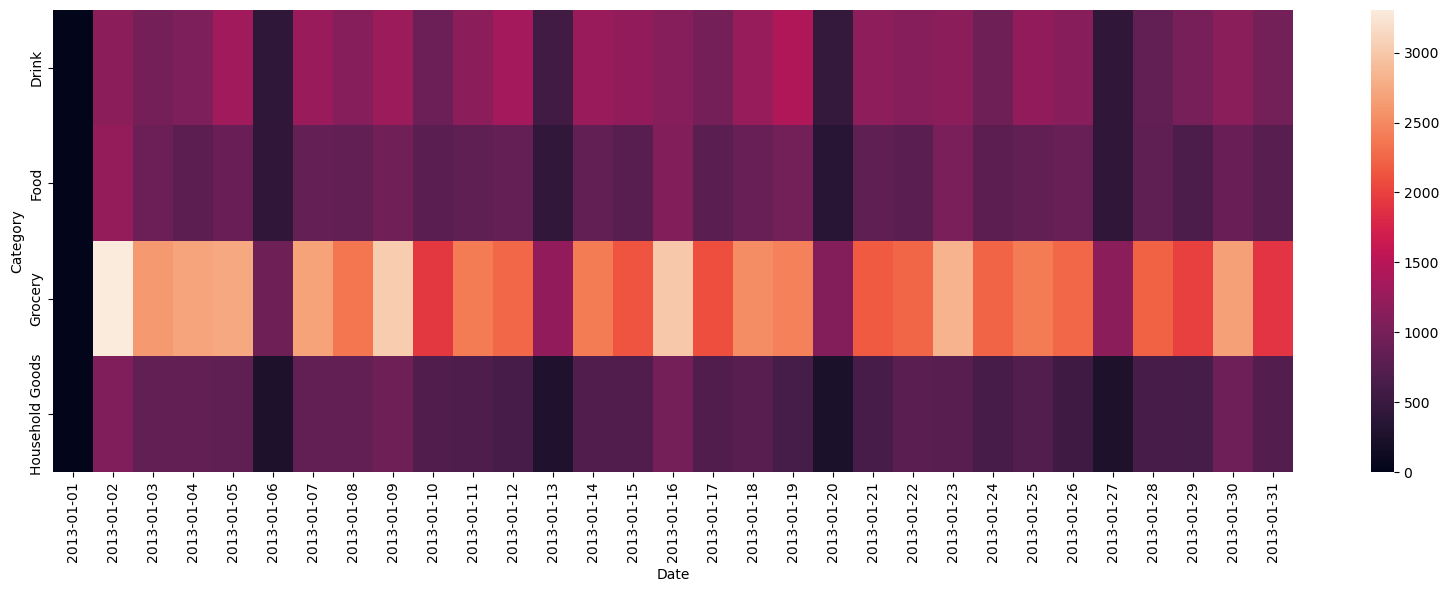

In [50]:
# sns.heatmap으로 시각화 할 수도 있습니다!

plt.figure(figsize = (20, 6))
sns.heatmap(temp3)
plt.show()

## **4.복습문제**

In [2]:
# 라이브러리 불러오기
import pandas as pd

In [4]:
sales = pd.read_csv("https://raw.githubusercontent.com/DA4BAM/dataset/master/ts_sales_simple.csv")
products = pd.read_csv("https://raw.githubusercontent.com/DA4BAM/dataset/master/ts_product_master.csv")
stores = pd.read_csv("https://raw.githubusercontent.com/DA4BAM/dataset/master/ts_store_master.csv")

1) sales에 금액(Amt) 변수를 추가하시오.
* Amt = Qty * Price

In [68]:
print(sales.head(2))
print(products.head(2))
print(stores.head(2))

   Order_ID        Date  Store_ID  Qty  Product_ID  Amt
0         3  2013-01-01         1  0.0           3  0.0
1         5  2013-01-01         1  0.0           5  0.0
   Product_ID Product_Code      SubCategory         Category  LeadTime  Price
0          20        HG001  Gardening Tools  Household Goods         2     50
1          27        HH001  Home Appliances  Household Goods         2    150
   Store_ID        City      State  Store_Type
0         1  Saint Paul  Minnesota           4
1         2  Saint Paul  Minnesota           4


In [20]:
# merge를 한 후에 'Amt' 변수를 추가해야 한다는 사실을 알게 되었다.
# 이전에는 sales 데이터 프레임에 바로 Amt를 추가했었다.

tmp1 = pd.merge(sales, products, how = 'inner', on = 'Product_ID')  # 겹치는 칼럼이 여러개라면 on을 반드시 써야 한다.

tmp1['Amt'] = tmp1['Qty'] * tmp1['Price']
tmp1.head(5)

,Order_ID,Date,Store_ID,Qty,Product_ID,Product_Code,SubCategory,Category,LeadTime,Price,Amt
0,3,2013-01-01,1,0.0,3,DB001,Beverage,Drink,2,8,0.0
1,5,2013-01-01,1,0.0,5,FB001,BAKERY,Food,2,6,0.0
2,7,2013-01-01,1,0.0,7,HC001,Cleaning,Household Goods,2,15,0.0
3,8,2013-01-01,1,0.0,8,FM001,Milk,Food,2,4,0.0
4,10,2013-01-01,1,0.0,10,GE001,EGGS,Grocery,2,5,0.0


2) City별 매출액

In [34]:
tmp2 = pd.merge(tmp1, stores)
tmp2.head()

,Order_ID,Date,Store_ID,Qty,Product_ID,Product_Code,SubCategory,Category,LeadTime,Price,Amt,City,State,Store_Type
0,3,2013-01-01,1,0.0,3,DB001,Beverage,Drink,2,8,0.0,Saint Paul,Minnesota,4
1,5,2013-01-01,1,0.0,5,FB001,BAKERY,Food,2,6,0.0,Saint Paul,Minnesota,4
2,7,2013-01-01,1,0.0,7,HC001,Cleaning,Household Goods,2,15,0.0,Saint Paul,Minnesota,4
3,8,2013-01-01,1,0.0,8,FM001,Milk,Food,2,4,0.0,Saint Paul,Minnesota,4
4,10,2013-01-01,1,0.0,10,GE001,EGGS,Grocery,2,5,0.0,Saint Paul,Minnesota,4


In [36]:
tmp2.groupby(['City'], as_index = False)['Amt'].sum()

,City,Amt
0,Albany,9.618918e+05
1,Annapolis,1.926923e+06
2,Asheville,5.699986e+05
3,Atlanta,3.374833e+06
4,Bloomington,1.154652e+06
5,Boston,9.879414e+05
6,Charlotte,1.229219e+06
7,Columbus,1.650586e+06
8,Harrisburg,1.345873e+06
9,Indianapolis,1.256235e+06


3) City별 카테고리별 매출액

In [27]:
tmp2.groupby(['City', 'Category'], as_index = False)['Amt'].sum()

,City,Category,Amt
0,Albany,Drink,2.367080e+05
1,Albany,Food,6.998561e+04
2,Albany,Grocery,3.676481e+05
3,Albany,Household Goods,2.875500e+05
4,Annapolis,Drink,3.507200e+05
...,...,...,...
79,Saint Paul,Household Goods,1.081224e+07
80,Wilmington,Drink,0.000000e+00
81,Wilmington,Food,0.000000e+00
82,Wilmington,Grocery,0.000000e+00


4) 매출액이 가장 높은 주(state) top 3

In [30]:
tmp3 = tmp2.groupby('State', as_index = False)['Amt'].sum()
tmp3.sort_values('Amt', ascending = False).head(3)

,State,Amt
6,Minnesota,4.733903e+07
8,North Carolina,1.133845e+07
0,Arizona,4.192750e+06


추가 문제

* 2013년 1월 세째 주 각 도시별 subCategory별 금액 비교
    1. 2013년 1월 세째 주
        * sales['Date']를 날짜 타입으로 변환
        * week 추가
        * sales에서 week가 3인 데이터 뽑기
    2. 각 도시별 subCategory별
        * 1의 결과에서...
        * stores와 inner merge
        * products와 inner merge
    3. 도시별 subCategory별 금액
        * Qty * Price로 Amt 추가
        * groupby
    4. 좀더 보기 좋게! pivot + heatmap
        * pivot
        * heatmap

In [44]:
tmp2.head(3)

,Order_ID,Date,Store_ID,Qty,Product_ID,Product_Code,SubCategory,Category,LeadTime,Price,Amt,City,State,Store_Type,Year,Month,Week
0,3,2013-01-01,1,0.0,3,DB001,Beverage,Drink,2,8,0.0,Saint Paul,Minnesota,4,2013,1,1
1,5,2013-01-01,1,0.0,5,FB001,BAKERY,Food,2,6,0.0,Saint Paul,Minnesota,4,2013,1,1
2,7,2013-01-01,1,0.0,7,HC001,Cleaning,Household Goods,2,15,0.0,Saint Paul,Minnesota,4,2013,1,1


In [50]:
# 1.
tmp2['Date'] = pd.to_datetime(tmp2['Date'])
tmp2['Year'] = tmp2['Date'].dt.year
tmp2['Month'] = tmp2['Date'].dt.month
tmp2['Week'] = tmp2['Date'].dt.isocalendar().week
tmp2.head()

tmp5 = tmp2.loc[(tmp2['Year']==2013) & (tmp2['Month']==1 ) & ( tmp2['Week']==3)]
tmp5.head(3)

,Order_ID,Date,Store_ID,Qty,Product_ID,Product_Code,SubCategory,Category,LeadTime,Price,Amt,City,State,Store_Type,Year,Month,Week
10530,23169,2013-01-14,1,1178.000,3,DB001,Beverage,Drink,2,8,9424.000,Saint Paul,Minnesota,4,2013,1,3
10531,23171,2013-01-14,1,281.286,5,FB001,BAKERY,Food,2,6,1687.716,Saint Paul,Minnesota,4,2013,1,3
10532,23173,2013-01-14,1,692.000,7,HC001,Cleaning,Household Goods,2,15,10380.000,Saint Paul,Minnesota,4,2013,1,3


In [52]:
tmp6 = tmp5.groupby(['City','SubCategory'], as_index = False)['Amt'].sum()
tmp6

,City,SubCategory,Amt
0,Albany,Agricultural products,67224.0
1,Albany,Alcohol,6336.0
2,Albany,BAKERY,7530.0
3,Albany,Beverage,45360.0
4,Albany,Cleaning,61365.0
...,...,...,...
289,Wilmington,Kitchen,0.0
290,Wilmington,Meats,0.0
291,Wilmington,Milk,0.0
292,Wilmington,Prepared,0.0


In [54]:
tmp7 = tmp6.pivot(index = 'SubCategory', columns = 'City', values = 'Amt')
tmp7

City,Albany,Annapolis,Asheville,Atlanta,Bloomington,Boston,Charlotte,Columbus,Harrisburg,Indianapolis,...,Minneapolis,Nashville,Oklahoma City,Olympia,Phoenix,Raleigh,Richmond,Sacramento,Saint Paul,Wilmington
SubCategory,,,,,,,,,,,,,,,,,,,,,
Agricultural products,67224.000000,134160.000,45108.0,229254.000000,90810.000000,68148.000000,81708.000000,118752.00000,88944.000,107418.000,...,154536.000,79128.000000,207342.00000,54828.00000,268398.00000,664980.000000,145746.000000,0.0,2.761452e+06,0.0
Alcohol,6336.000000,3672.000,4848.0,10200.000000,2868.000000,2220.000000,6252.000000,5364.00000,1068.000,1704.000,...,2760.000,1956.000000,6828.00000,9228.00000,10476.00000,44112.000000,4404.000000,0.0,1.286280e+05,0.0
BAKERY,7530.000000,17250.000,4098.0,49734.276180,9234.000000,7842.000000,17148.714180,20010.03000,9972.000,15900.000,...,21186.000,6996.000000,24076.29000,9668.99412,28739.11800,116199.744000,17779.842000,0.0,3.838290e+05,0.0
Beverage,45360.000000,86632.000,24192.0,98968.000000,28768.000000,47720.000000,53464.000000,41656.00000,25056.000,34848.000,...,119272.000,31480.000000,64512.00000,61608.00000,118592.00000,363656.000000,59416.000000,0.0,1.865480e+06,0.0
Cleaning,61365.000000,126525.000,40245.0,215130.000000,90750.000000,68655.000000,64050.000000,98655.00000,103230.000,95040.000,...,157725.000,78045.000000,203970.00000,47850.00000,217200.00000,574995.000000,131010.000000,0.0,2.379060e+06,0.0
EGGS,1790.000000,2045.000,1160.0,8795.000000,3325.000000,1115.000000,6405.000000,4220.00000,1105.000,2380.000,...,2115.000,1370.000000,8390.00000,3170.00000,5765.00000,29835.000000,5730.000000,0.0,1.451550e+05,0.0
Frozen,2066.453000,4537.717,1421.0,36590.779290,4971.063971,2834.807971,10270.466000,24646.81000,3625.928,1669.791,...,4836.359,3223.785000,21226.23100,7185.27200,33027.95500,69453.869029,17064.440913,0.0,5.234791e+05,0.0
Gardening Tools,0.000000,0.000,0.0,2350.000000,0.000000,0.000000,1000.000000,900.00000,0.000,150.000,...,500.000,0.000000,700.00000,1400.00000,300.00000,4250.000000,550.000000,0.0,3.710000e+04,0.0
Home Appliances,0.000000,0.000,0.0,0.000000,0.000000,0.000000,0.000000,0.00000,0.000,0.000,...,0.000,0.000000,0.00000,0.00000,0.00000,0.000000,0.000000,0.0,0.000000e+00,0.0


<Axes: xlabel='City', ylabel='SubCategory'>

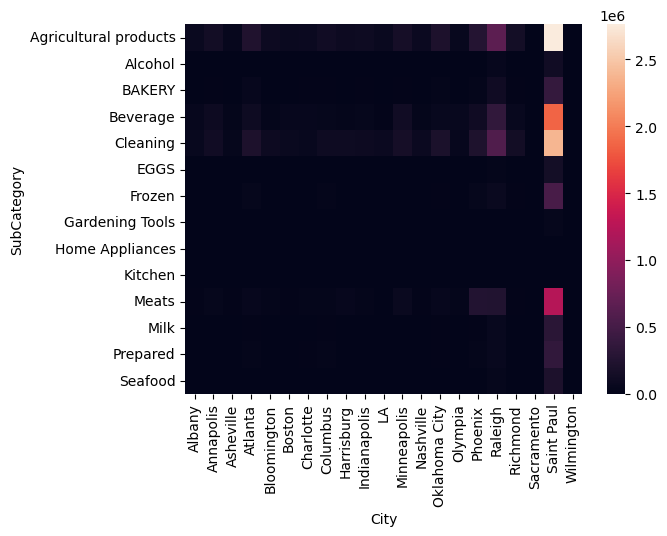

In [62]:
sns.heatmap(tmp7)